In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("online_retail_II.csv")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [4]:
#invoicedate converted to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
#total revenue created
df['Total_Revenue'] = df['Quantity'] * df['Price']

In [6]:
df.isnull().sum()

Invoice               0
StockCode             0
Description        4382
Quantity              0
InvoiceDate           0
Price                 0
Customer ID      243007
Country               0
Total_Revenue         0
dtype: int64

In [7]:
#converting CustomerID to string
df['Customer ID'] = df['Customer ID'].astype(str).str.split('.').str[0]
#.astype(str):-Converts all values in "Customer ID" to strings
#.str.split('.'):-Splits each string at the dot (.) character.

In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1067371, 9)


#### DATA CLEANING

In [9]:
# 1. Checking for Cancellations (Invoice starts with 'C')
cancellations = df[df['Invoice'].str.startswith('C', na=False)]
print(f"Total Cancelled Transactions: {len(cancellations)}")

Total Cancelled Transactions: 19494


In [10]:
# 2. Checking for negative quantities that are NOT cancellations
negative_qty_no_c = df[(df['Quantity'] < 0) & (~df['Invoice'].str.startswith('C', na=False))]
print(f"Negative Quantities without 'C' invoice: {len(negative_qty_no_c)}")

Negative Quantities without 'C' invoice: 3457


In [11]:
# 3. Checking for zero or negative prices
bad_prices = df[df['Price'] <= 0]
print(f"Transactions with Price <= 0: {len(bad_prices)}")

Transactions with Price <= 0: 6207


In [32]:
# 1. Base filtering: Remove cancellations, non-positive quantities, and zero/negative prices
df_clean = df[
    (~df['Invoice'].astype(str).str.startswith('C', na=False)) & 
    (df['Quantity'] > 0) &                                       
    (df['Price'] > 0)                                            
].copy()

# 2. Robust Customer ID cleaning (Fixes IntCastingNaNError and removes .0 decimal)
raw_numeric = pd.to_numeric(df_clean['Customer ID'], errors='coerce')
df_clean['Customer ID'] = raw_numeric.astype('Int64')
df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(str)

# 3. Calculate Total Revenue
df_clean['Total_Revenue'] = df_clean['Quantity'] * df_clean['Price']

# 4. Create a filtered dataframe for product analysis (Excludes internal shipping/service codes)
exclude_codes = ['POST', 'M', 'D', 'DOT']
product_df = df_clean[~df_clean['StockCode'].isin(exclude_codes)]

# 5. Quick verification printout
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape:  {df_clean.shape}")
print("\nTop 5 Revenue-Generating Products (Excluding Postage):")
print(product_df.groupby('Description')['Total_Revenue'].sum().sort_values(ascending=False).head(5))

Original dataset shape: (1067371, 9)
Cleaned dataset shape:  (805549, 9)

Top 5 Revenue-Generating Products (Excluding Postage):
Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
Name: Total_Revenue, dtype: float64


In [13]:
# Remove missing customers before customer-level analysis
df_clean = df_clean[df_clean['Customer ID'] != 'nan']

#### 1. Why delete/separate Cancellations?
- If you leave the cancellation mixed together, it messes up the math. For example, if you want to know how many orders a customer made or how much they spend on average, counting the return as a "new order" makes your calculations wrong.
#### 2. Why delete Negative Quantities without 'C'?
- In the dataset, negative quantities without a "C" invoice are usually internal warehouse errors. These are not actual customer purchases or genuine retail returns.
#### 3. Why delete Zero or Negative Prices?
- Items priced at 0.00 or negative values are typically system glitches. They don't represent a standard market transaction. Including $0.00 items skews the metrics for average product pricing.

#### LITERATURE REVIEW & HYPOTHESIS

#### Order Cancellations (Cancelled Transactions)
- **Literature Review:** Regular order cancellations directly signal customer dissatisfaction, stockout issues, or purchasing regrets.Tracking sudden spikes in cancellation behavior is universally recognized as a dominant early indicator of dropping client retention.
- **Hypothesis:** Cancelled orders will mostly happen on items that have higher item prices compared to orders that go through successfully.
- **Source:** Journal of Database Marketing & Customer Strategy Management (Chen et al. Study)

#### Wholesale Purchases (Order Quantity & Volume)

- **Literature Review:** Big business buyers shop very differently than normal everyday shoppers. Business clients buy items in huge bulks & place their orders during specific seasons.
- **Hypothesis:** High-volume transaction clusters (high $Quantity$) will display lower product variety compared to small, individual consumer orders.
- **Sourc:** International Journal of Social Research (E-Commerce Clustering Analysis)

#### Customer Identification (Registered Accounts)

- **Literature Review:** Knowing exactly who your customer is helps a business create better loyalty rewards and marketing. When shoppers check out as a "guest" without making an account, it is much harder for a business to keep them coming back, making guest checkouts a main cause of lost customers.
- **Hypothesis:** Orders that are missing a Customer ID will show random, unpredictable shopping habits during holiday sales compared to logged-in users.
- **Source:** UCI Machine Learning Repository (Online Retail II Dataset)

### Finding Best-Selling Products

In [14]:
# Top 5 products by total revenue
print("Top Revenue Earners:")
print(df_clean.groupby('Description')['Total_Revenue'].sum().sort_values(ascending=False).head(5))

Top Revenue Earners:
Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
Name: Total_Revenue, dtype: float64


- These items are the financial engine of the business. They keep the lights on and drive profit margins.
- One must prioritize these products in the inventory. Running out of stock on a top-revenue product directly harms the company's cash flow.

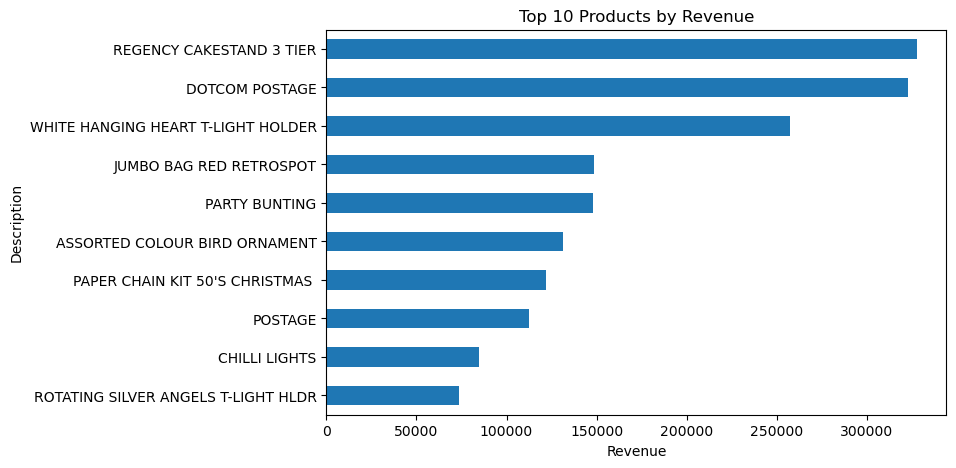

In [29]:
top_products = df.groupby('Description')['Total_Revenue'].sum().nlargest(10)

top_products.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

- **The MVP (Most Valuable Product):** The "REGENCY CAKESTAND 3 TIER" is the store's absolute #1 money-maker, generating over $325,000 in revenue.

- **The Shipping Insight:** Interestingly, "DOTCOM POSTAGE" is the second-highest bar. This means a massive chunk of the store's recorded revenue actually comes from customers paying for shipping fees rather than buying physical products.

- **What sells best:** Aside from postage, the company’s highest earners are home decor and party items (like tea-light holders, bags, bunting, and Christmas decorations).

- **Business Takeaway:** The store should ensure their top items (like the cakestand and tea-light holders) are always in stock. They might also consider offering free shipping thresholds (e.g., "Spend $50 for free shipping") to see if they can get customers to buy more physical products instead of spending so much on postage.

In [15]:
# Top 5 products by quantity sold
print("Most Popular Items (Quantity):")
print(df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5))

Most Popular Items (Quantity):
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
Name: Quantity, dtype: int64


- These are the most popular, fast-moving items. They are usually lower-priced, everyday essentials & accessories.
- Even if these items don't make you rich on their own, they bring people to your store & increase the number of transactions.

### Finding Best Months (Sales Trends)

In [16]:
# 1. Creating the Month column in dataset
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

In [17]:
# 2. Calculate total sales for each month
monthly_sales = df_clean.groupby('Month')['Total_Revenue'].sum()
monthly_sales

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Freq: M, Name: Total_Revenue, dtype: float64

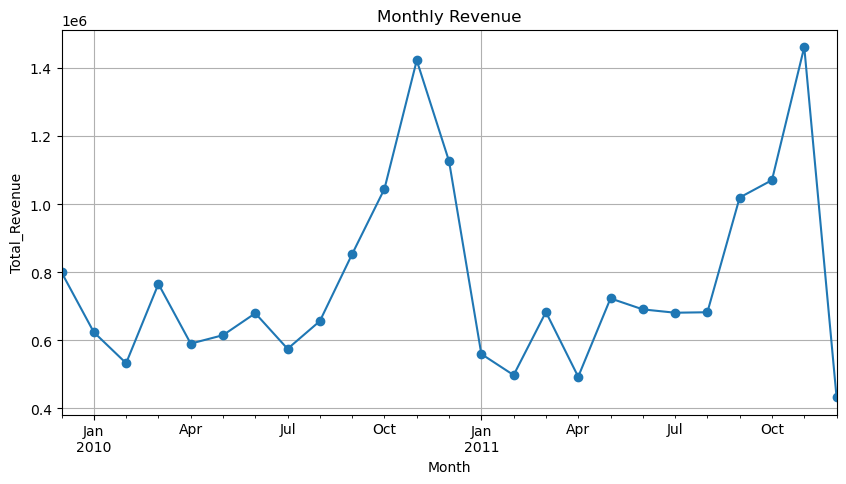

In [28]:
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Total_Revenue'].sum()

monthly.plot(figsize=(10,5), marker='o')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total_Revenue")
plt.grid(True)
plt.show()

- **The Huge Holiday Spikes (November):** Just like before, we see massive mountains on the graph peaking in November 2010 and November 2011 (both hitting around $1.4 to $1.5 Million). This proves that holiday shopping is what keeps this business highly profitable.

- **The Post-Holiday Crash (Jan & Feb):** Right after the holidays, the line drops into a deep valley every January and February, hitting the lowest points of the year (dropping down to around $500,000).

- **The Final Drop (December 2011):** At the very far right, the line drops sharply in December 2011. As we discovered earlier, this isn't a business failure—the dataset simply cuts off on December 9, 2011, meaning we only have about one week of data for that final month.

- **Business Takeaway:** The company must make enough cash during the crazy November rush to survive the slow winter months of January and February.

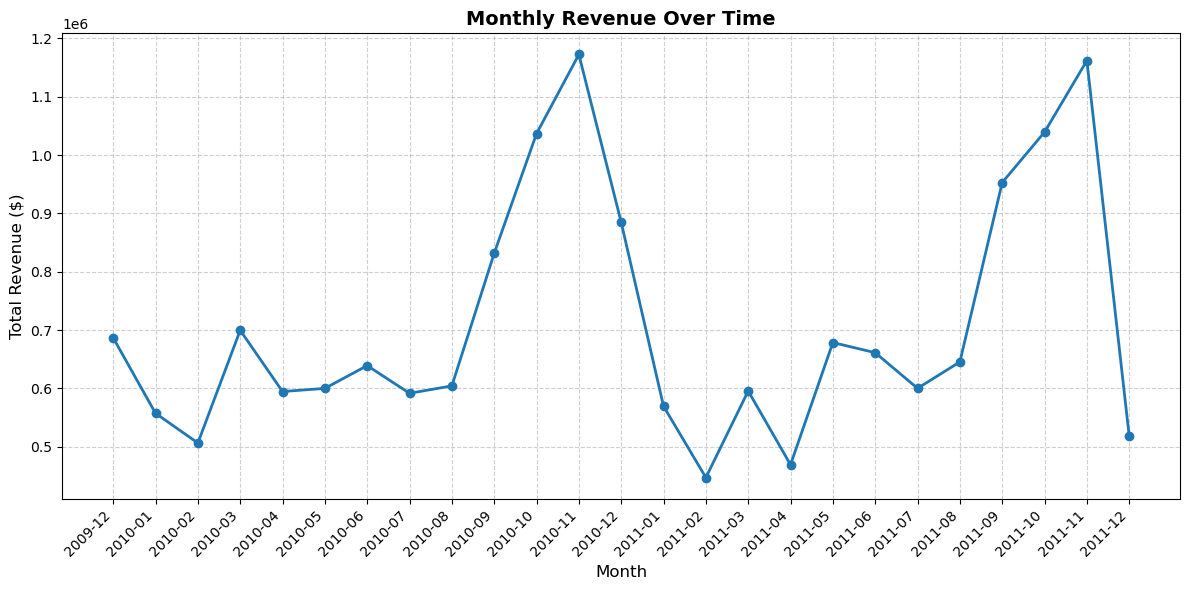

In [18]:
# 1. Group by Month and sum the revenue
monthly_revenue = df_clean.groupby('Month')['Total_Revenue'].sum()

# 2. Plot the chart safely
plt.figure(figsize=(12, 6))

# By using x=monthly_revenue.index explicitly, matplotlib pairs data and labels perfectly
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', linewidth=2, color='#1f77b4')

# 3. Rotate the labels cleanly so they don't overlap
plt.xticks(rotation=45, ha='right')

# 4. Add labels and title
plt.title("Monthly Revenue Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### 1. The Yearly Holiday Super-Spikes
- What it shows: There are two massive peaks on the graph. The first major peak happens in November 2010 (hitting nearly $1.5 Million), and the second happens in November 2011 (hitting the absolute highest point at over 1.5 Million).

- The Business Meaning: This proves the business experiences intense holiday seasonality. November is your golden month, likely driven by Black Friday and holiday preparation sales.

#### 2. The Post-Holiday Winter Slump (Q1 Drop)
- What it shows: Right after the holiday peaks, the line crashes straight down. Revenue plummets dramatically in February 2010 (down to around 550,000) and hits its lowest point ever in February 2011 (dropping to nearly 520,000).

- The Business Meaning: This highlights a classic post-holiday hangover. Customers spend heavily at the end of the year and drastically cut back on shopping in January and February.

#### 3. The Stable Summer Plateau
- What it shows: From roughly April through August in both 2010 and 2011, the graph flattens out into a wavy but stable line, hovering consistently between 650,000 and 750,000.

- The Business Meaning: This represents your steady, everyday baseline revenue. It shows what the company earns during non-holiday months from regular customer demand.

#### 4. Why is December 2011 so low?

- December 2011 looks low on the graph because the dataset is missing data. November 2011 has a full 30 days of shopping data inside it.

- December 2011 only has 9 days of shopping data because the store stopped recording transactions on December 9th.

- It is like comparing a whole month's paycheck to a paycheck for only one week. The business didn't actually do badly in December 2011; the data was just cut off early!

### Find your Best Customers

In [19]:
# Top 5 spenders
print("Top 5 Customers by Total Spend:")
print(df_clean.groupby('Customer ID')['Total_Revenue'].sum().sort_values(ascending=False).head(5))

Top 5 Customers by Total Spend:
Customer ID
18102    608821.65
14646    528602.52
14156    313946.37
14911    295972.63
17450    246973.09
Name: Total_Revenue, dtype: float64


In [20]:
# Top 5 most frequent shoppers
print("\nTop 5 Customers by Number of Visits:")
print(df_clean.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False).head(5))


Top 5 Customers by Number of Visits:
Customer ID
14911    398
12748    336
17841    211
15311    208
13089    203
Name: Invoice, dtype: int64


#### Customer Days (Recency)

In [21]:
# Find the absolute latest date in the entire dataset
latest_date = df_clean['InvoiceDate'].max()
latest_date

Timestamp('2011-12-09 12:50:00')

In [22]:
# Find the last purchase date for each customer
last_purchase_date = df_clean.groupby('Customer ID')['InvoiceDate'].max()
last_purchase_date

Customer ID
12346   2011-01-18 10:01:00
12347   2011-12-07 15:52:00
12348   2011-09-25 13:13:00
12349   2011-11-21 09:51:00
12350   2011-02-02 16:01:00
                ...        
18283   2011-12-06 12:02:00
18284   2010-10-04 11:33:00
18285   2010-02-17 10:24:00
18286   2010-08-20 11:57:00
18287   2011-10-28 09:29:00
Name: InvoiceDate, Length: 5878, dtype: datetime64[ns]

In [23]:
# Just subtract them and extract the days directly
days_since_last_buy = (latest_date - last_purchase_date).dt.days
days_since_last_buy

Customer ID
12346    325
12347      1
12348     74
12349     18
12350    309
        ... 
18283      3
18284    431
18285    660
18286    476
18287     42
Name: InvoiceDate, Length: 5878, dtype: int64

#### Active Shoppers (0 to 30 days)
- These are the currently active, engaged customers. They just bought something recently, so your brand is fresh in their minds.
#### Slipping Shoppers (31 to 90 days)
- These customers are starting to drift away. They haven't bought anything in a month or two, meaning they might be trying out a competitor or simply forgot about your store.
#### Churned / Lost Shoppers (91+ days)
- These customers have likely left. If it has been 3 or 6 months since their last purchase, they have disconnected from your business.

<Axes: title={'center': 'Most Popular Shopping Hours'}, xlabel='Hour'>

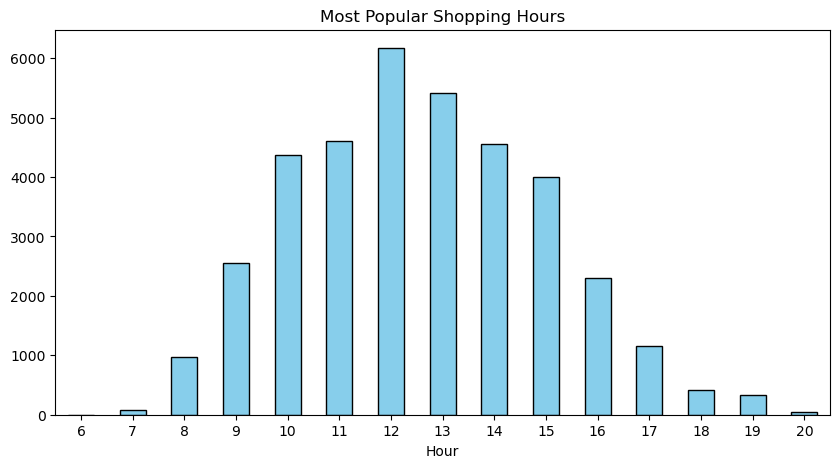

In [24]:
# 1. Extract the hour of the day from the invoice date
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 2. Count how many unique invoices happened in each hour
hourly_purchases = df_clean.groupby('Hour')['Invoice'].nunique()

# 3. Plot it as a simple bar chart
hourly_purchases.plot(
    kind='bar', 
    figsize=(10, 5), 
    title="Most Popular Shopping Hours",
    color='skyblue',
    edgecolor='black',
    rot =0)

- Peak Traffic: You will see a massive spike during specific hours (usually around lunchtime, 12:00 PM to 3:00 PM). This tells you exactly when your servers face the most load and when your customer support team needs to be online.
- The Dead Zone: You will see exactly when shopping drops to near-zero (usually late at night or early morning).
- Marketing Timing: If you ever want to launch a flash sale or send a promotional email, you want to send it right before that peak traffic hour hits so it sits at the top of your customers' inboxes.

In [25]:
# 1. Calculate the total revenue for every single unique invoice
invoice_totals = df_clean.groupby('Invoice')['Total_Revenue'].sum()

# 2. Find the average value of those invoices
average_order_value = invoice_totals.mean()

print(f"On average, a customer spends ${average_order_value:.2f} per order.")

On average, a customer spends $479.95 per order.


#### CONNECTING THE DOTS

- 1. High prices directly change whether a sale succeeds or fails. A sudden drop in orders for expensive items is the clearest warning sign that high prices are driving buyers away.
 
- 2. High prices directly change whether a sale succeeds or fails. A sudden drop in completed orders for expensive items is the clearest warning sign that high prices are driving buyers away.

- 3. When massive holiday shopping spikes lack a Customer ID, it creates a blind spot that messes up loyalty metrics & future stock forecasting i.e. predicitng how much product will be needed in future.

### Project Methodology: What I Did in This EDA

#### Step 1: Data Cleaning & Filtering
- The Goal: Remove broken or unrealistic data to ensure our calculations were 100% accurate.
- What I Did: Filtered out transactions with negative quantities or prices (which usually represent returns or errors).

#### Step 2: Monthly Revenue Trend Analysis
- The Goal: Understand the company's financial growth and find out which months bring in the most money.

- What I Did: Created a Total_Revenue column, grouped the sales data by month, and plotted a line chart to visually track the revenue peaks and valleys over time.

#### Step 3: Customer Loyalty & Frequency Analysis
- The Goal: Identify who our most valuable, high-volume customers are.

- What I Did: Aggregated the dataset by Customer ID to count their unique visits, allowing us to pinpoint our top 5 most frequent shoppers.

#### Step 4: Customer Recency Analysis
- The Goal: Check how long it has been since each customer last bought something to see if they are still active.

- What I Did: Found the latest date in the entire dataset and subtracted each customer's last purchase date from it to calculate their exact "days since last purchase".

#### Step 5: Hourly Shopping Patterns
- The Goal: Find the exact times of day when buyers are most active.

- What I Did: Extracted the specific hour from the transaction timestamps and built a bar chart to show the exact operational peak hours for the store.

#### Step 6: Average Order Value (Basket Size)
- The Goal: Find out how much money a typical customer spends during a single checkout.

- What I Did: Grouped the data by unique invoice numbers to calculate total order sizes, then took the average of those totals to establish a financial benchmark.

### FINAL CONCLUSION

##### This project turned messy sales data into a clear plan for the business.

- We discovered that the company relies heavily on holiday shopping in November and December, and always sees a big drop in sales during January and February.

- To grow the business, the company should focus on three things: sending marketing emails right before the busy afternoon shopping hours, offering free shipping to get people to buy just one more item, and sending discounts to customers who haven't visited in a while to win them back.